In [46]:
import mitsuba as mi
import drjit as dr
import matplotlib.pyplot as plt
import matplotlib as mpl
import sionna.rt as rt
import numpy as np

In [47]:
# from Anshul's notebook
mat_lunar_highland = rt.RadioMaterial(
    name="lunar-highland",
    thickness=11,
    relative_permittivity=2.7,
    conductivity=10**(-12.5),
    scattering_coefficient=0.4,
    xpd_coefficient=0.1,
    scattering_pattern='lambertian',
    frequency_update_callback=None,
    color=None,
    props=None)

mat_lunar_mare = rt.RadioMaterial(
    name="lunar-mare",
    thickness=5,
    relative_permittivity=2.7,
    conductivity=10**(-12.5),
    scattering_coefficient=0.4,
    xpd_coefficient=0.1,
    scattering_pattern='lambertian',
    frequency_update_callback=None,
    color=None,
    props=None)

In [48]:
def default_array(num_rows: int = 1, num_cols: int = 1,
                  vertical_spacing: float = 0.5, horizontal_spacing: float = 0.5,
                  pattern: str = "iso", polarization: str = "V"):
    return rt.PlanarArray(num_rows=num_rows,
                       num_cols=num_cols,
                       vertical_spacing=vertical_spacing,
                       horizontal_spacing=horizontal_spacing,
                       pattern=pattern,
                       polarization=polarization)

In [49]:
def paths_to_coverage_map(paths, is_mesh=False):
    """
    Converts paths into the equivalent coverage map values.
    The coverage map is assumed to be a ssquare.
    """
    # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
    a_real, a_imag = paths.a
    a = a_real.numpy() + 1j*a_imag.numpy()

    # Transmit precoding
    # Assume default precoding
    # [num_rx, num_rx_ant, num_tx, num_paths]
    a /= np.sqrt(a.shape[3])
    a = np.sum(a, axis=3)

    # Sum energy of paths
    a = np.square(np.abs(a))
    # [num_rx, num_tx]
    a = np.sum(a, axis=(1, 3))

    # Swap dims
    # [num_tx, num_rx]
    a = a.T

    if not is_mesh:
        # Reshape to coverage map
        n = int(np.sqrt(a.shape[1]))
        shape = [a.shape[0], n, n]
        a = np.reshape(a, shape)

    return a

In [50]:
from sionna.rt import Scene, RadioMaterial, HolderMaterial, PlanarArray, Transmitter

N = 100
vert_x, vert_y = np.meshgrid(
    np.linspace(0, 10, N),
    np.linspace(0, 10, N),
    indexing="xy")
vert_z = (np.sin(2 * vert_x) + np.sin(2 * vert_y)) / 2
vert_xyz = np.stack([vert_x, vert_y, vert_z], axis=2).reshape(-1, 3)

# Triangulate
vertex_indices = np.arange(N * N)
is_last_column = (vertex_indices + 1) % N == 0
is_last_row = vertex_indices // N == N - 1
ii = vertex_indices[~is_last_row & ~is_last_column]
faces = np.stack([[ii, ii + 1, ii + N + 1], [ii, ii + N + 1, ii + N]])
faces = np.concatenate(faces.T, axis=-1).T

# Create scene
props = mi.Properties()
props["material"] = mat_lunar_highland
# props["material"] = rt.ITURadioMaterial("mat", itu_type="concrete", thickness=10)
# props["material"] = RadioMaterial("mat", thickness=10, relative_permittivity=100)
# Sionna requires bsdfs to be wrapped in HolderMaterial
props["material"] = HolderMaterial(props)
mi_mesh = mi.Mesh(name="terrain",
                    vertex_count=vert_xyz.shape[0],
                    face_count=faces.shape[0], 
                    props=props)
mi_mesh_params = mi.traverse(mi_mesh)
mi_mesh_params["vertex_positions"] = mi.Float(vert_xyz.ravel().astype(np.float32))
mi_mesh_params["faces"] = mi.UInt(faces.ravel().astype(np.uint32))
mi_mesh_params.update()
mi_scene = mi.load_dict({
    "type": "scene",
    "terrain": mi_mesh
})

scene = Scene(mi_scene)
scene.tx_array = default_array()
scene.rx_array = default_array(polarization="VH")
tx = Transmitter(name="tx",
                 position=mi.Point3f(0, 0, 1),
                 orientation=mi.Point3f(0,0,0),
                 power_dbm=100)
scene.add(tx)

In [51]:
terrain = scene.get("terrain")
meas_surf = terrain.clone(name="measurement_surface")
rt.transform_mesh(meas_surf.mi_mesh, translation=[0, 0, 0.01])

In [52]:
specular_reflection = True
diffuse_reflection = True
refraction=True 
max_depth = 5
los = True

In [53]:
# Compute the radio map
rm_solver = rt.RadioMapSolver()
rm_solver.loop_mode = "evaluated"
rm = rm_solver(scene,
            measurement_surface=meas_surf,
            samples_per_tx=int(1e7),
            max_depth=max_depth,
            los=los,
            specular_reflection=specular_reflection,
            diffuse_reflection=diffuse_reflection,
            refraction=refraction)

# Check for NaN or Inf
assert not (dr.any(dr.isinf(rm.path_gain)) or dr.any(dr.isnan(rm.path_gain)))

In [54]:
# Add receivers at the cell centers
for i, pos in enumerate(rm.cell_centers.numpy().T):
    scene.remove(f"rx-{i}")
    scene.add(rt.Receiver(name=f"rx-{i}",
                        position=pos,
                        display_radius=0.1,
                        orientation=mi.Point3f(0, 0, 0)))

# Compute radio map using the path solver
solver = rt.PathSolver()
paths = solver(scene,
                samples_per_src = 10000,
                max_num_paths_per_src=int(1e8),
                max_depth=max_depth,
                los=los,
                specular_reflection=specular_reflection,
                diffuse_reflection=diffuse_reflection,
                refraction=refraction)

In [55]:
gain_ap = paths_to_coverage_map(paths, is_mesh=True)[0]
gain_rt = rm.path_gain[0].numpy()

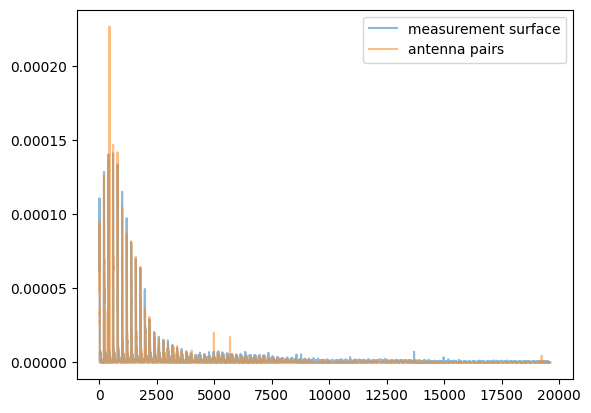

In [56]:
plt.plot(gain_rt, alpha=0.5, label="measurement surface")
plt.plot(gain_ap, alpha=0.5, label="antenna pairs")
plt.legend()

In [57]:
# convert per-face values to rectangular grid cell values
grid_rt = np.nanmean([gain_rt[0::2], gain_rt[1::2]], axis=0).reshape(N-1, N-1)
grid_ap = np.nanmean([gain_ap[0::2], gain_ap[1::2]], axis=0).reshape(N-1, N-1)

/var/folders/dp/9xqdy2vn535883dxlm82nwtc0000gn/T/ipykernel_42740/1741446827.py:10: RuntimeWarning: divide by zero encountered in divide
  err = np.abs(grid_rt - grid_ap) / np.abs(grid_ap)
/var/folders/dp/9xqdy2vn535883dxlm82nwtc0000gn/T/ipykernel_42740/1741446827.py:10: RuntimeWarning: invalid value encountered in divide
  err = np.abs(grid_rt - grid_ap) / np.abs(grid_ap)


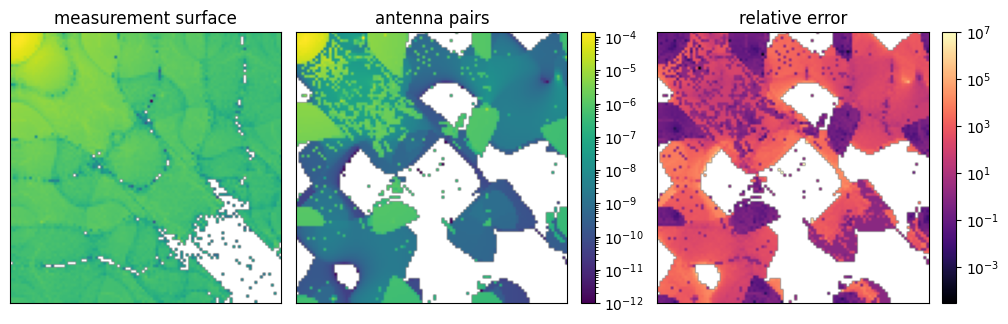

In [58]:
fig, axs = plt.subplots(ncols=3, layout="constrained")
fig.set_size_inches(10, 3.125)
norm = mpl.colors.LogNorm(
    max(1e-12, np.min([grid_rt, grid_ap])),
    np.max([grid_rt, grid_ap]))
axs[0].imshow(grid_rt, norm=norm)
axs[1].imshow(grid_ap, norm=norm)
mappable = mpl.cm.ScalarMappable(norm=norm)
plt.colorbar(mappable, ax=axs[1])
err = np.abs(grid_rt - grid_ap) / np.abs(grid_ap)
mappable = axs[2].imshow(err, cmap="magma", norm="log")
for ax in axs:
    ax.set(xticks=[], yticks=[])
axs[0].set_title("measurement surface")
axs[1].set_title("antenna pairs")
axs[2].set_title("relative error")
plt.colorbar(mappable, ax=axs[2])

In [59]:
with np.errstate(divide="ignore", invalid="ignore"):
    err = np.abs(gain_rt - gain_ap) / gain_ap
nmse_db = 10*np.log10(np.mean(err[np.isfinite(err)]**2))
nmse_db

np.float32(95.13752)

In [60]:
for i, pos in enumerate(rm.cell_centers.numpy().T):
    scene.remove(f"rx-{i}")
scene.preview(radio_map=rm, show_devices=True);